In [18]:
from langgraph.graph import StateGraph, START,END

In [19]:
from typing import TypedDict

class BMIState(TypedDict):
    height:float
    weight:float
    res:float
    category:str

In [20]:
def calculateBMI(state:BMIState)->BMIState:
    weight=state['weight']
    height=state['height']
    bmi=weight/(height**2)
    state['res']=round(bmi,2)
    return state
    

In [21]:
def label_bmi(state:BMIState)->BMIState:
    bmi=state['res']
    if(bmi<18.5):
        state['category']="Underweight"
    elif(18.5<=bmi<25):
        state['category']="Normal"
    elif(25<bmi<30):
        state['category']="Overweight"
    else:
        state['category']="Obese"
    return state

In [22]:
graph=StateGraph(BMIState)
graph.add_node('calculateBMI',calculateBMI)
graph.add_node("label_bmi",label_bmi)
graph.add_edge(START,'calculateBMI')
graph.add_edge("calculateBMI","label_bmi")
graph.add_edge("label_bmi",END)
workflow= graph.compile()

In [23]:
workflow.invoke({"weight":80,"height":1.85})

{'height': 1.85, 'weight': 80, 'res': 23.37, 'category': 'Normal'}

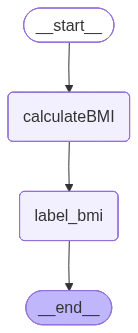

In [24]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())